# Neural Network - "Squiggle Fitting Machine"

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Main ideas behind neural network

In [6]:
# calculation to show how it's working ...

input_data = np.array([0])
weights=np.array([-34.4, -2.52])
bias = np.array([2.14, 1.29])

at_layer_1 = input_data*weights + bias

print("x value for activation function 1: {}".format(at_layer_1[0]))
print("x value for activation function 2: {}".format(at_layer_1[1]))

x value for activation function 1: 2.14
x value for activation function 2: 1.29


In [4]:
# Defining activation function

def softplus_activation(x):
    return np.log(1+np.exp(x))

In [7]:
softplus_activation(at_layer_1)

array([2.2512326 , 1.53315853])

In [78]:
def print_activation(weight_matrix, bias_matrix, activation_fn, node=1):
    node_val = []
    x_val = []
    value_=[]
    for val in np.linspace(0,1,100):
        x_val.append(val)
        value = val*weight_matrix + bias_matrix
        node_val.append(activation_fn(value[node-1]))
        value_.append(value)
    
    return x_val, node_val, value_

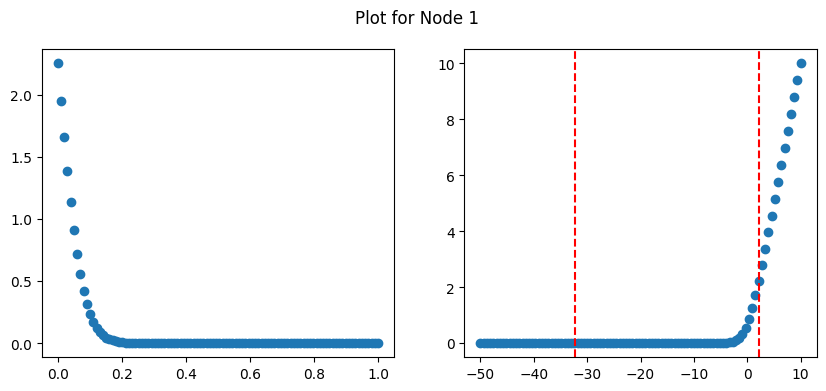

In [95]:
x, y, before_activation = print_activation(weights, bias, softplus_activation, node=1)
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(x,y)
ax[1].scatter(np.linspace(-50,10,100),softplus_activation(np.linspace(-50,10,100)))
ax[1].axvline(x=min([j[0] for j in before_activation]), 
              color='red', linestyle='--')
ax[1].axvline(x=max([j[0] for j in before_activation]), 
              color='red', linestyle='--')
plt.suptitle("Plot for Node 1")
plt.show()

> - This is a portion of the activation function.
> - **Key Note :** Since, weight is -ve, the above portion is mirror image of a portion of the activation function.

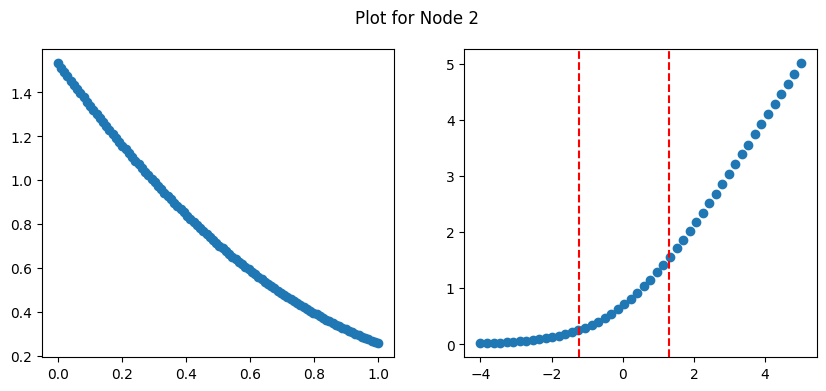

In [94]:
x, y, before_activation = print_activation(weights, bias, softplus_activation, node=2)
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(x,y)
ax[1].scatter(np.linspace(-4,5,50),softplus_activation(np.linspace(-4,5,50)))
ax[1].axvline(x=min([j[1] for j in before_activation]), 
              color='red', linestyle='--')
ax[1].axvline(x=max([j[1] for j in before_activation]), 
              color='red', linestyle='--')
plt.suptitle("Plot for Node 2")
plt.show()

> - **Key Observation :** Since, the weight is small, we get to pick a smaller portion from the sofplus activation function.

## Let's go now ...

In [69]:
# define architecture of the neural network
network_architecture = [2,1]     # 1 input node (DEFAULT), 2 nodes in first hidden layer, 1 output node (DEFAULT)
weight_dict={1:np.array([-34.4, -2.52]),
             2: np.array([-1.3, 2.28])
             }
bias_dict={1: np.array([2.14, 1.29]),
           2: np.array([-0.58])
           }

at_layer={}

input_data = np.array([0])
# input_data_array = [input_data]
# input_data_array = [np.array([0]),  np.array([0.5])]
input_data_array = np.linspace(0,1,50)

capture_to_plot=[]

for j in [np.array([0.2])]:
    print("Input data: {}".format(j))
    for index,layer_size in enumerate(network_architecture):
        layer_num = index+1

        
        print("\tAt layer: {}".format(layer_num))
        print("\t\tInput data: {}".format(j))

        if layer_num == 1:
            val = j*weight_dict[layer_num] + bias_dict[layer_num]
        else:
            val = np.dot(j, weight_dict[layer_num]) + bias_dict[layer_num]

        at_layer_ = softplus_activation(val)
        at_layer[layer_num] = at_layer_

        print("\t\t\tWeights: {}".format(weight_dict[layer_num]))
        print("\t\t\tBias: {}".format(bias_dict[layer_num]))
        print("\t\t\tValue before activation: {}".format(val))
        print("\t\t\tValue after activation: {}".format(at_layer_))
        
        j = at_layer_
    capture_to_plot.append(at_layer_)

Input data: [0.2]
	At layer: 1
		Input data: [0.2]
			Weights: [-34.4   -2.52]
			Bias: [2.14 1.29]
			Value before activation: [-4.74   0.786]
			Value after activation: [0.00870069 1.16146202]
	At layer: 2
		Input data: [0.00870069 1.16146202]
			Weights: [-1.3   2.28]
			Bias: [-0.58]
			Value before activation: [2.05682252]
			Value after activation: [2.1771442]


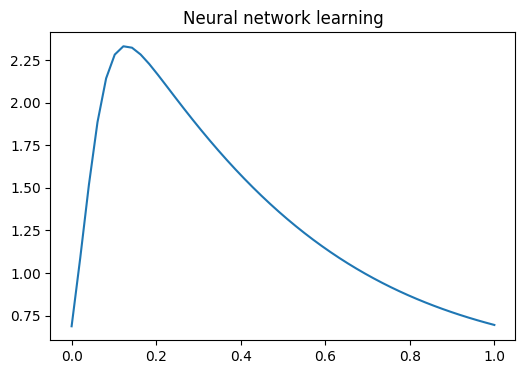

In [108]:
plt.figure(figsize=(6,4))
plt.plot(np.linspace(0,1,50), capture_to_plot)
plt.title("Neural network learning")
plt.show()

## Learning of the squiggle - Let's see

In [85]:
# define architecture of the neural network
network_architecture = [2,1]     # 1 input node (DEFAULT), 2 nodes in first hidden layer, 1 output node (DEFAULT)
weight_dict={1:np.array([-34.4, -2.52]),
             2: np.array([-1.3, 2.28])
             }
bias_dict={1: np.array([2.14, 1.29]),
           2: np.array([-0.58])
           }

input_data = np.array([0])
capture_to_plot=[]

def output_from_node(weight_, bias_, input_):
    val = input_*weight_
    if len(bias_)==1:
        return val, softplus_activation(np.sum(val) + bias_)
    else:
        return val, softplus_activation(val+bias_)

In [86]:
capture_to_plot=[]
for input_data in np.linspace(0,1,50):
    _, input_to_layer1 = output_from_node(weight_dict[1], bias_dict[1], 
                                          input_data)
    capture, _ = output_from_node(weight_dict[2], bias_dict[2], 
                                  input_to_layer1)
    capture_to_plot.append(capture)

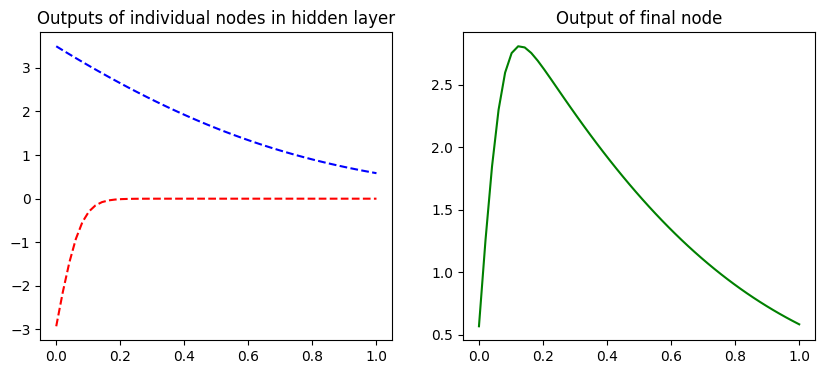

In [93]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(np.linspace(0,1,50), [j[0] for j in capture_to_plot], color='red', linestyle='--')
ax[0].plot(np.linspace(0,1,50), [j[1] for j in capture_to_plot], color='blue', linestyle="--")
ax[0].set_title("Outputs of individual nodes in hidden layer")
ax[1].plot(np.linspace(0,1,50), [np.sum(j) for j in capture_to_plot], color='green')
ax[1].set_title("Output of final node")
plt.show()

## Backpropagation

### Key Formulas
> - Derivative of Loss function wrt Predicted value,$$\frac{dSSR}{dPredicted}=-2*\sum{(Observed_i-Predicted_i)}$$
> - Derivative of Loss function wrt weights, $$\frac{dSSR}{dW}=\frac{dSSR}{dPredicted}*(\text{activation function output})$$